<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [2]:
URL =  "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"

### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Test Environment


In [5]:
import pandas as pd
df = pd.read_csv(file_name, header=0)

<ipython-input-5-01847c6a6bce>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [6]:
desc = df.describe(include='all')

In [7]:
display(desc)

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
count,238.000000,238,238.000000,238,238.000000,238.000000,238.000000,234.000000,238.000000,238.000000,238.000000,233.000000,238.000000
unique,NaN,11,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Dell,NaN,Full HD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,71,NaN,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,118.500000,NaN,3.205882,NaN,2.151261,1.058824,5.630252,37.269615,2.360084,7.882353,245.781513,1.862232,1462.344538
std,68.848868,NaN,0.776533,NaN,0.638282,0.235790,1.241787,2.971365,0.411393,2.482603,34.765316,0.494332,574.607699
min,0.000000,NaN,1.000000,NaN,1.000000,1.000000,3.000000,30.480000,1.200000,4.000000,128.000000,0.810000,527.000000
25%,59.250000,NaN,3.000000,NaN,2.000000,1.000000,5.000000,35.560000,2.000000,8.000000,256.000000,1.440000,1066.500000
50%,118.500000,NaN,3.000000,NaN,2.000000,1.000000,5.000000,38.100000,2.500000,8.000000,256.000000,1.870000,1333.000000
75%,177.750000,NaN,4.000000,NaN,3.000000,1.000000,7.000000,39.624000,2.700000,8.000000,256.000000,2.200000,1777.000000


In [8]:
desc.to_csv('describe_all.csv')

In [9]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
sns.set(style="whitegrid")

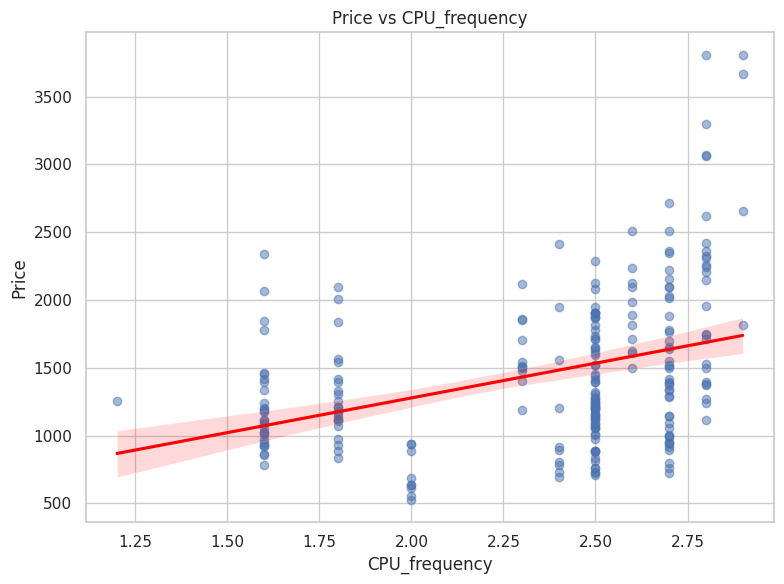

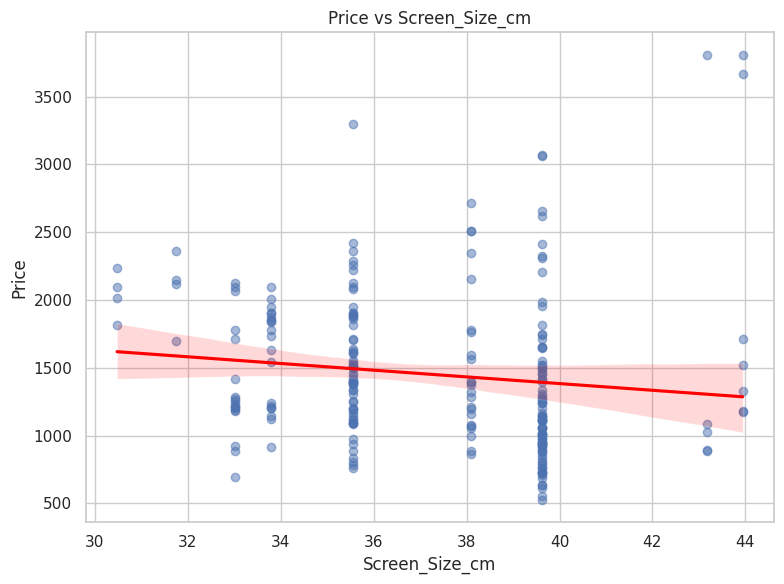

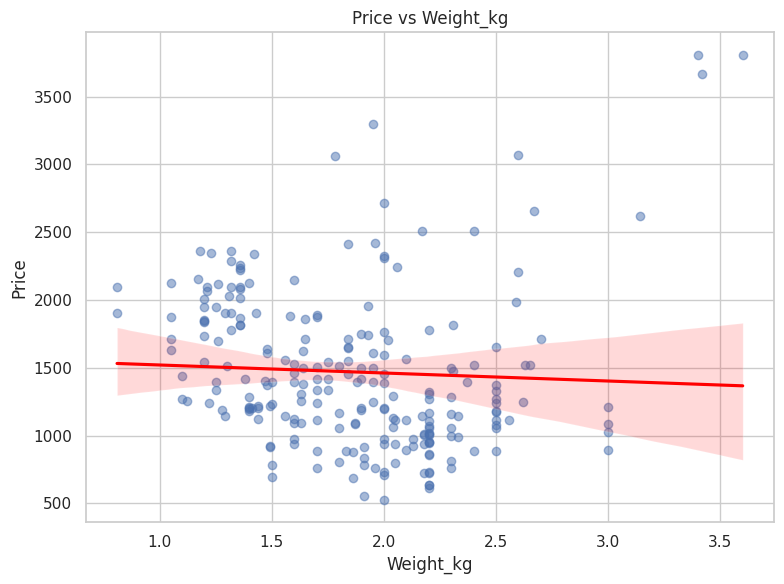

In [11]:
numeric_regs = ["CPU_frequency", "Screen_Size_cm", "Weight_kg"]

for col in numeric_regs: 
    plt.figure(figsize=(8, 6)) 
    sns.regplot(x=col, y="Price", data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}) 
    plt.title(f"Price vs {col}") 
    plt.xlabel(col) 
    plt.ylabel("Price") 
    plt.tight_layout() 
    plt.show()

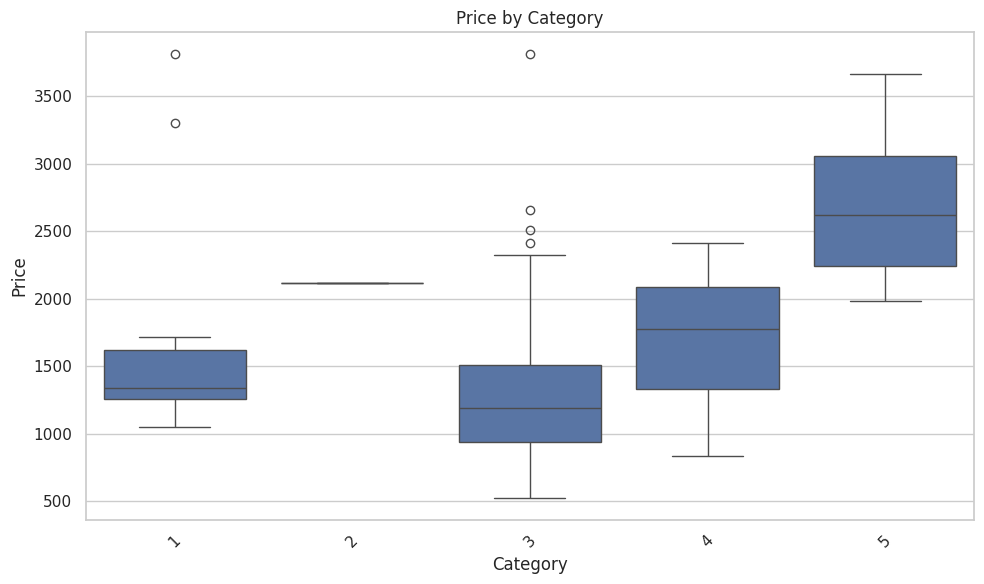

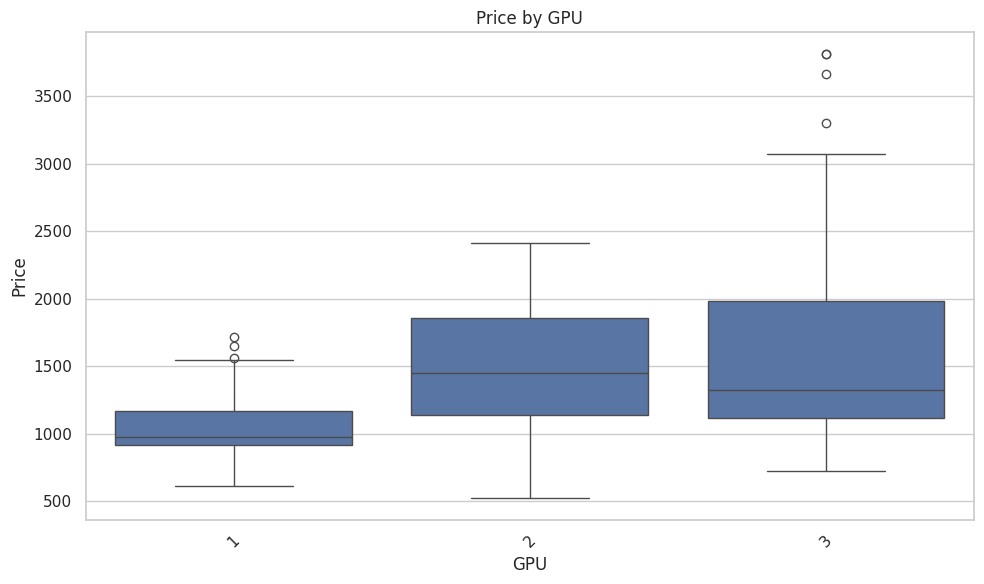

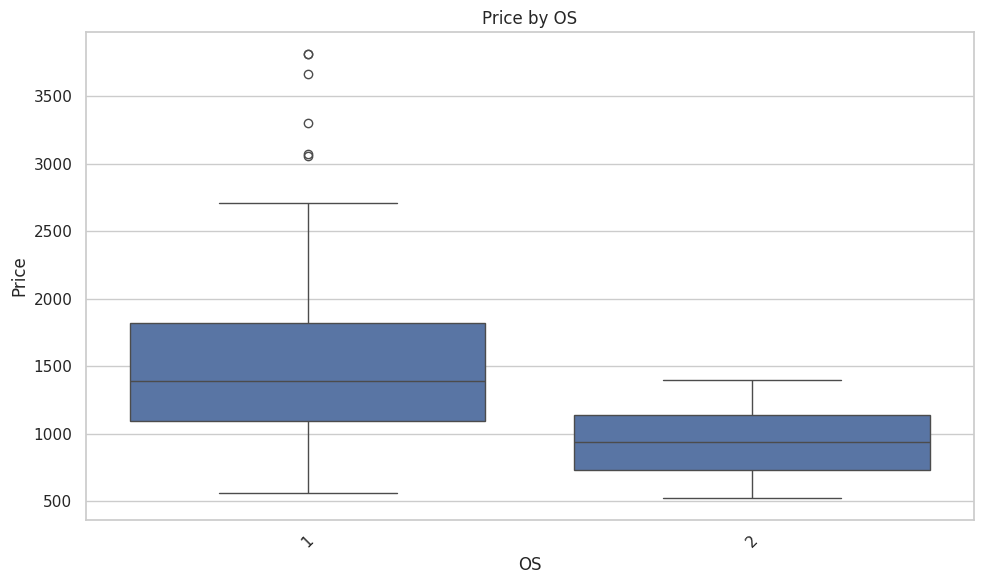

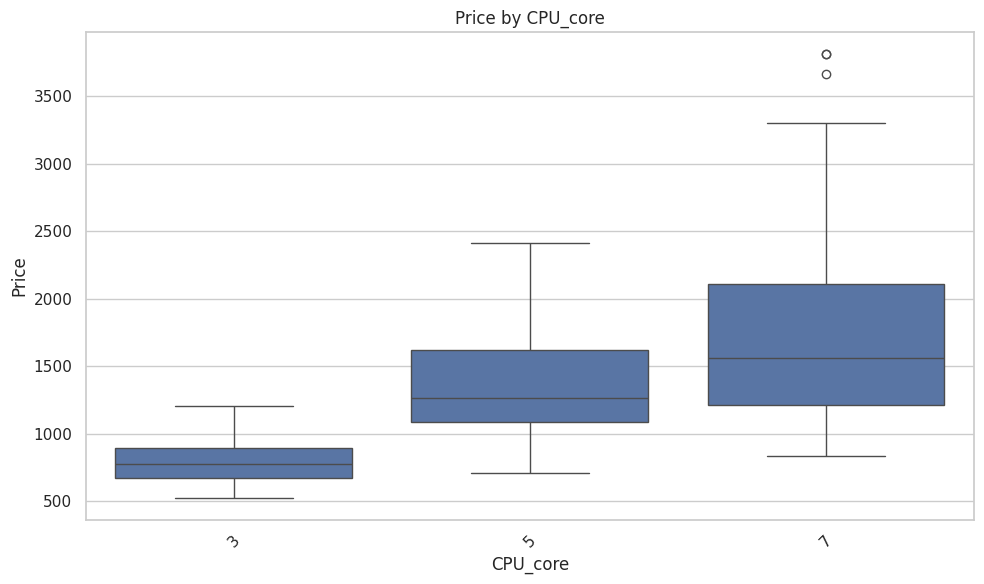

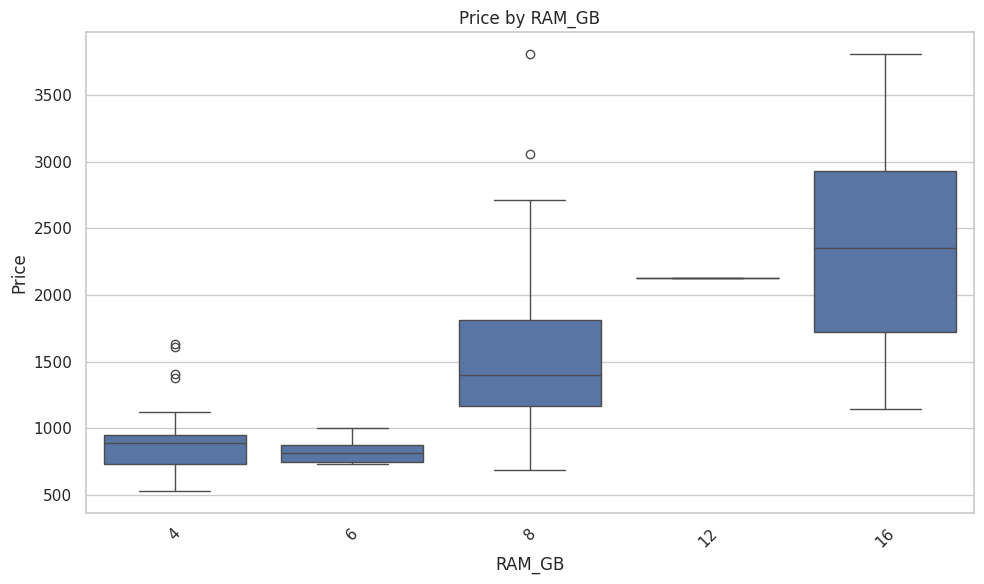

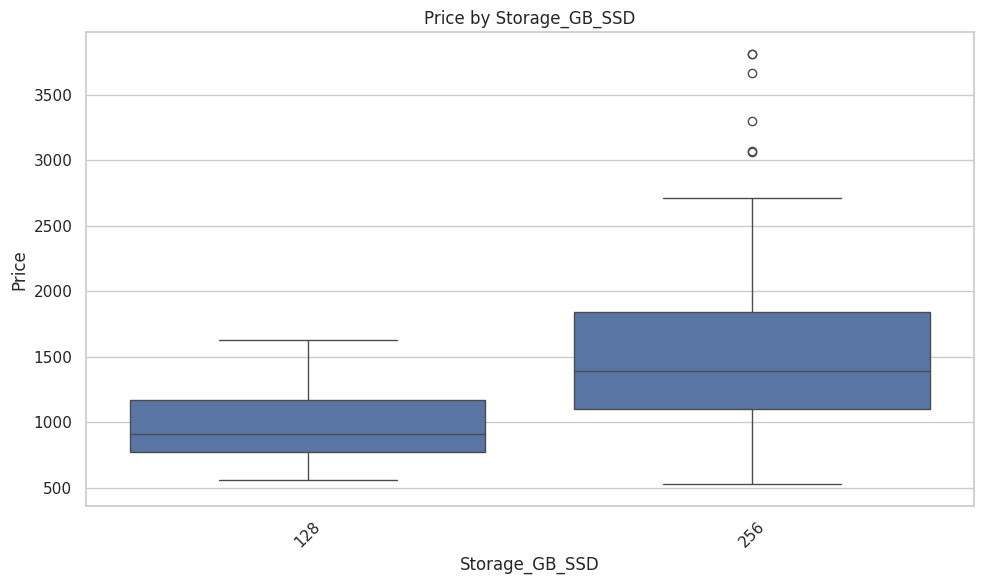

In [12]:
cat_attrs = ["Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"]

for col in cat_attrs:
    plt.figure(figsize=(10, 6)) 
    sns.boxplot(x=col, y="Price", data=df) 
    plt.title(f"Price by {col}") 
    plt.xlabel(col) 
    plt.ylabel("Price") 
    plt.xticks(rotation=45) 
    plt.tight_layout() 
    plt.show()

In [13]:
import numpy as np 
from scipy.stats import pearsonr



## Get numeric columns and exclude the target variable 'Price'

In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist() 
if 'Price' in numeric_cols: 
    numeric_cols.remove('Price')

results = [] 
for col in numeric_cols:
    subset = df[[col, 'Price']].dropna() 
    if subset.shape[0] < 2: # Not enough data to compute correlation
        continue
    r, p = pearsonr(subset[col], subset['Price']) 
    results.append({ 'Attribute': col, 'Correlation_value': abs(r),  'Pearson_coefficient': r,  'p_value': p })

corr_df = pd.DataFrame(results)

In [15]:
display(corr_df)

,Attribute,Correlation_value,Pearson_coefficient,p_value
0,Unnamed: 0,0.321933,0.321933,3.851058e-07
1,Category,0.286243,0.286243,7.225696e-06
2,GPU,0.288298,0.288298,6.166950e-06
3,OS,0.221730,-0.221730,5.696643e-04
4,CPU_core,0.459398,0.459398,7.912950e-14
5,Screen_Size_cm,0.128233,-0.128233,5.009166e-02
6,CPU_frequency,0.366666,0.366666,5.502463e-09
7,RAM_GB,0.549297,0.549297,3.681561e-20
8,Storage_GB_SSD,0.243421,0.243421,1.489892e-04
9,Weight_kg,0.050707,-0.050707,4.410942e-01


In [16]:
plt.style.use('seaborn-darkgrid') 

## Ensure the required columns exist

In [17]:
has_gpu = 'GPU' in df.columns 
has_cpu = 'CPU_core' in df.columns 
has_price = 'Price' in df.columns

if not (has_gpu and has_cpu and has_price): 
    print("Missing required columns. Found - GPU:", has_gpu, ", CPU_core:", has_cpu, ", Price:", has_price) 
else: # Create pivot table: rows = GPU, columns = CPU_core, values = mean Price 
    pivot = df.pivot_table(index='GPU', columns='CPU_core', values='Price', aggfunc='mean') 
    print("Pivot table shape:", pivot.shape) 
    display(pivot)

Pivot table shape: (3, 3)


CPU_core,3,5,7
GPU,,,
1,769.250000,998.500000,1167.941176
2,785.076923,1462.197674,1744.621622
3,784.000000,1220.680000,1945.097561


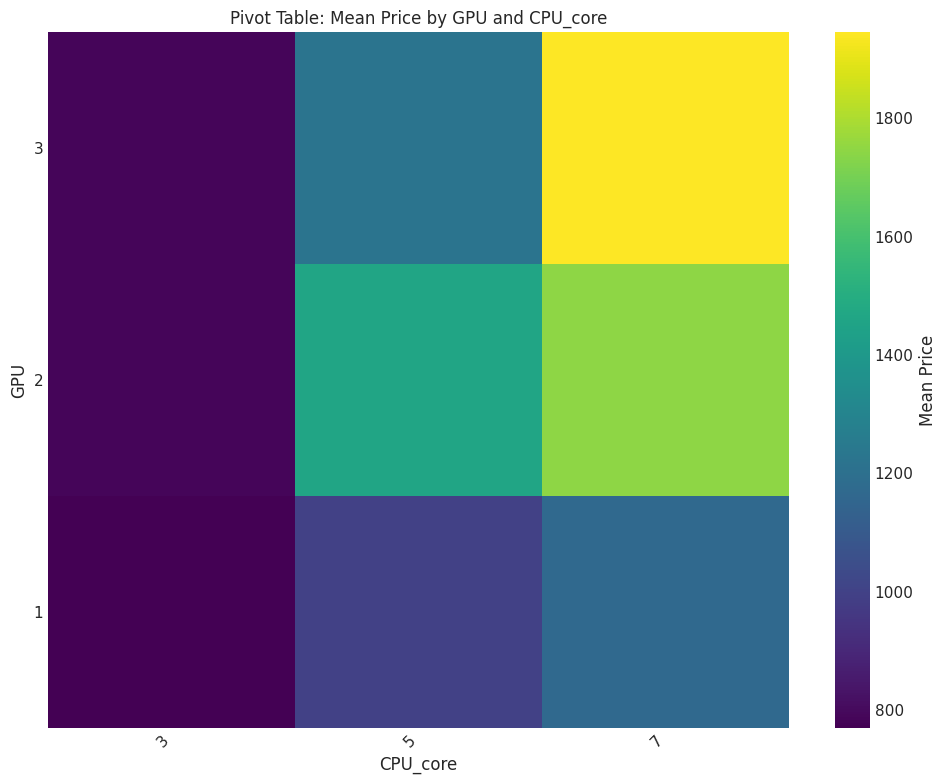

In [18]:
if 'pivot' in locals() and not pivot.empty: 
    data = pivot.values 
    # Replace NaNs so pcolormesh can render the grid 
    data_filled = np.where(np.isnan(data), 0, data)

    fig, ax = plt.subplots(figsize=(10, 8))
    c = ax.pcolormesh(data_filled, cmap='viridis', shading='auto')
    
    # Set axis labels and ticks to match pivot table
    ax.set_xticks(np.arange(pivot.shape[1]) + 0.5)
    ax.set_yticks(np.arange(pivot.shape[0]) + 0.5)
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    and_ylabels = list(pivot.index)
    ax.set_yticklabels(and_ylabels)
    
    ax.set_xlabel('CPU_core')
    ax.set_ylabel('GPU')
    fig.colorbar(c, ax=ax, label='Mean Price')
    plt.title('Pivot Table: Mean Price by GPU and CPU_core')
    plt.tight_layout()
    plt.show()
else: 
    print("Pivot table not available. Ensure the required columns exist and data is sufficient.")

In [19]:
# Keep appending the code generated to this cell, or add more cells below this to execute in parts
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

In [20]:
def preprocess_dataframe(df, target_col='Price', drop_index_col=True, verbose=False):
    """
    Returns:
      - df_std: features transformed with StandardScaler for numeric cols (and OneHotEncoded categoricals)
      - df_minmax: features transformed with MinMaxScaler for numeric cols (and OneHotEncoded categoricals)
      - y: target values if target_col exists in df, else None
    """
    df = df.copy()

    # Drop the index-like column if present
    if drop_index_col and 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
        if verbose:
            print("Dropped column 'Unnamed: 0'")

    # Separate target if present
    if target_col in df.columns:
        y = df[target_col]
        X = df.drop(columns=[target_col])
        if verbose:
            print(f"Target column '{target_col}' found and separated from features.")
    else:
        y = None
        X = df
        if verbose:
            print(f"Target column '{target_col}' not found. Using all columns as features.")

    # Identify categorical vs numeric columns
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numeric_cols = [c for c in X.columns if c not in categorical_cols]

    if verbose:
        print(f"Categorical columns: {categorical_cols}")
        print(f"Numeric columns: {numeric_cols}")

    # Preprocessing for numeric features: impute then scale
    numeric_imputer = SimpleImputer(strategy='median')
    std_scaler = StandardScaler()
    minmax_scaler = MinMaxScaler()
    std_num = Pipeline([('imputer', numeric_imputer),
                        ('scaler', std_scaler)])
    minmax_num = Pipeline([('imputer', numeric_imputer),
                           ('scaler', minmax_scaler)])

    # Preprocessing for categorical features: impute then one-hot encode
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    onehot = OneHotEncoder(handle_unknown='ignore')
    cat_pipe = Pipeline([('imputer', categorical_imputer),
                        ('onehot', onehot)])

    # Two separate transformers: one with StandardScaler, one with MinMaxScaler
    preprocessor_std = ColumnTransformer(
        transformers=[
            ('num', std_num, numeric_cols),
            ('cat', cat_pipe, categorical_cols)
        ]
    )

    preprocessor_minmax = ColumnTransformer(
        transformers=[
            ('num', minmax_num, numeric_cols),
            ('cat', cat_pipe, categorical_cols)
        ]
    )

    # Fit/transform on the features
    X_std = preprocessor_std.fit_transform(X)
    X_minmax = preprocessor_minmax.fit_transform(X)

    # Get feature names for the transformed data (for nicer DataFrames)
    # Note: get_feature_names_out is supported by scikit-learn >= 0.23
    names_std = preprocessor_std.get_feature_names_out(input_features=X.columns)
    names_minmax = preprocessor_minmax.get_feature_names_out(input_features=X.columns)

    df_std = pd.DataFrame(X_std, columns=names_std, index=X.index)
    df_minmax = pd.DataFrame(X_minmax, columns=names_minmax, index=X.index)
    return df_std, df_minmax, y

In [21]:
df = pd.read_csv('dataset.csv')
df_std, df_minmax, y = preprocess_dataframe(df, target_col='Price', drop_index_col=True, verbose=True)

print("Standardized features shape:", df_std.shape)
print("Min-Max scaled features shape:", df_minmax.shape)
df_std.to_csv('data_std.csv', index=False)
df_minmax.to_csv('data_minmax.csv', index=False)

Dropped column 'Unnamed: 0'
Target column 'Price' found and separated from features.
Categorical columns: ['Manufacturer', 'Screen']
Numeric columns: ['Category', 'GPU', 'OS', 'CPU_core', 'Screen_Size_cm', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_kg']
Standardized features shape: (238, 22)
Min-Max scaled features shape: (238, 22)


In [22]:
import pandas as pd

def read_csv_with_headers(path, header_rows=1, sep=',', encoding=None, flatten_multiheader=False):
    """
    Read a CSV into a DataFrame with configurable header rows.
    - header_rows = 1 -> first row is the header (default)
    - header_rows > 1 -> first 'header_rows' rows form a MultiIndex header
    - flatten_multiheader: if True and a MultiIndex header exists, flatten to single level
    """
    if header_rows < 1:
        raise ValueError("header_rows must be >= 1")

    header = 0 if header_rows == 1 else list(range(header_rows))
    df = pd.read_csv(path, header=header, sep=sep, encoding=encoding)

    if flatten_multiheader and isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join([str(c) for c in tup if c is not None]) for tup in df.columns.values]

    return df

In [23]:
def missing_values_per_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a DataFrame listing columns that have missing values, with:
    - column: column name
    - n_missing: number of missing values in the column
    - pct_missing: percentage of missing values
    - dtype: data type of the column

    Only columns with at least one missing value are included.
    """
    # counts of missing values per column
    n_missing = df.isnull().sum()
    total = len(df)

    # build result DataFrame
    result = pd.DataFrame({
        'column': df.columns,
        'n_missing': n_missing.values,
        'pct_missing': (n_missing.values / total * 100).round(2),
        'dtype': df.dtypes.values
    })

    # filter to columns with any missing values and sort by missing count
    result = result[result['n_missing'] > 0].sort_values(by='n_missing', ascending=False).reset_index(drop=True)
    return result

In [24]:
df = read_csv_with_headers('dataset.csv')

In [25]:
print(missing_values_per_column(df))

           column  n_missing  pct_missing    dtype
0       Weight_kg          5         2.10  float64
1  Screen_Size_cm          4         1.68  float64


## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
